In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cv2
import tensorflow as tf

from keras.layers import Flatten, Dense
from keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras.applications.mobilenet import MobileNet, preprocess_input 
from keras.losses import categorical_crossentropy

In [25]:
base_model = MobileNet( input_shape=(224,224,3), include_top= False )

for layer in base_model.layers:
  layer.trainable = False


x = Flatten()(base_model.output)
x = Dense(units=7 , activation='softmax' )(x)

# creating our model.
model = Model(base_model.input, x)


model.compile(optimizer='adam', loss= categorical_crossentropy , metrics=['accuracy']  )

In [26]:
# Paths
train_dir = "data/train"
test_dir = "data/test"

# Parameters
img_size = (224, 224)   # MobileNet default
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2
)

# Only rescale for testing
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Load test dataset
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 34068 images belonging to 7 classes.
Found 2388 images belonging to 7 classes.


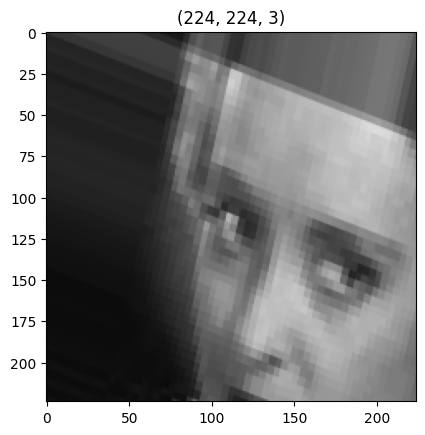

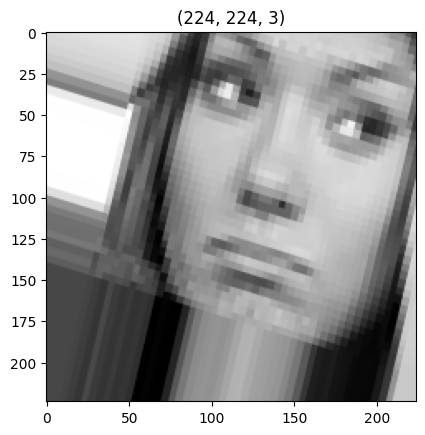

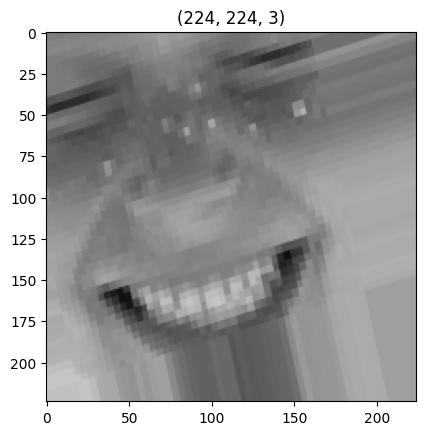

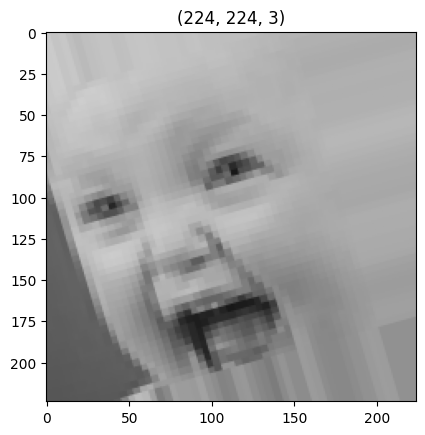

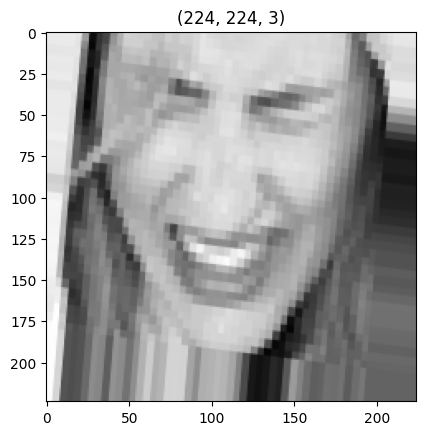

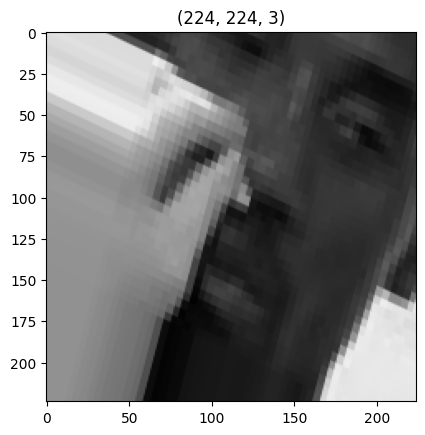

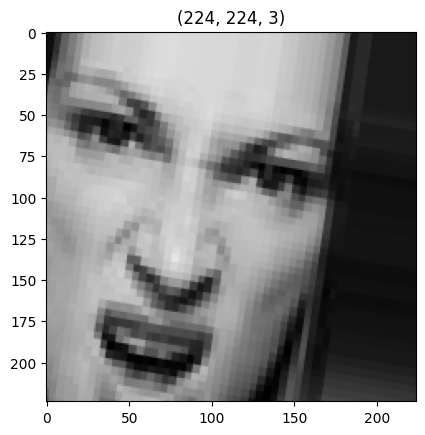

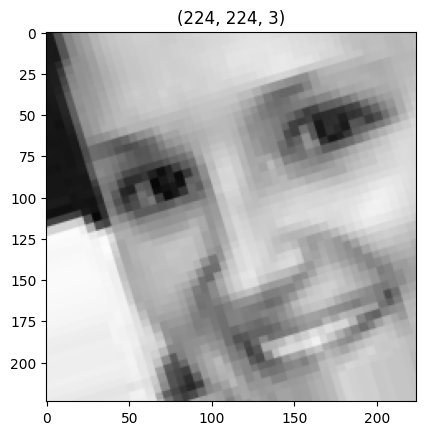

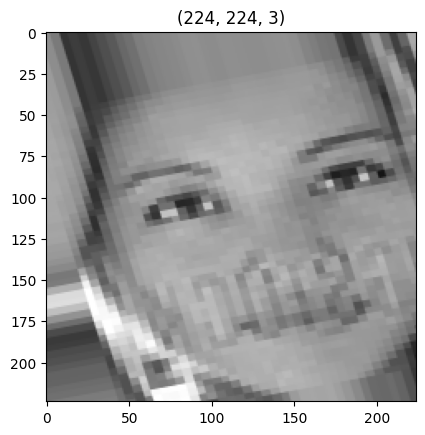

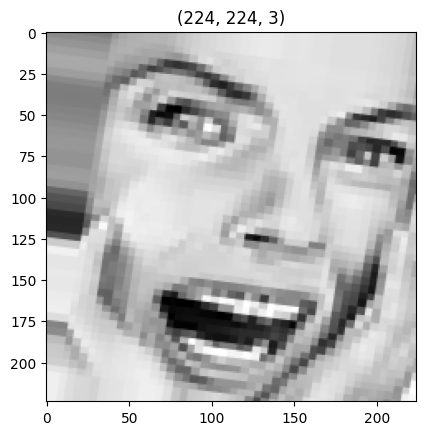

In [27]:
# Corrected code
# Corrected code
t_img , label = next(train_generator)

#-----------------------------------------------------------------------------
# function when called will prot the images 
def plotImages(img_arr, label):
  """
  input  :- images array 
  output :- plots the images 
  """
  count = 0
  for im, l in zip(img_arr,label) :
    plt.imshow(im)
    plt.title(im.shape)
    plt.axis = False
    plt.show()
    
    count += 1
    if count == 10:
      break

#-----------------------------------------------------------------------------
# function call to plot the images 
plotImages(t_img, label)

In [28]:


## having early stopping and model check point 

from keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta= 0.01 , patience= 5, verbose= 1, mode='auto')

# model check point
mc = ModelCheckpoint(filepath="best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto')

# puting call back in a list 
call_back = [es, mc]
     

# Corrected and updated code
hist = model.fit(train_generator, 
                 steps_per_epoch=10, 
                 epochs=30, 
                 validation_data=test_generator, 
                 validation_steps=8, 
                 callbacks=[es,mc])
     


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.1638 - loss: 11.5358
Epoch 1: val_accuracy improved from None to 0.28516, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 922ms/step - accuracy: 0.1844 - loss: 12.5646 - val_accuracy: 0.2852 - val_loss: 9.1416
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.2906 - loss: 7.6752
Epoch 2: val_accuracy did not improve from 0.28516
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 848ms/step - accuracy: 0.2812 - loss: 7.8181 - val_accuracy: 0.2695 - val_loss: 8.0932
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.2545 - loss: 6.9902
Epoch 3: val_accuracy did not improve from 0.28516
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 814ms/step - accuracy: 0.2594 - loss: 6.5658 - val_accuracy: 0.2695 - val_loss: 10.8557
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.2256 - loss: 7.6320
Epoch 4: val_accuracy improved from 0.28516 to 0.30469, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 822ms/step - accuracy: 0.2750 - loss: 6.6035 - val_accuracy: 0.3047 - val_loss: 7.7633
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.3077 - loss: 6.4152
Epoch 5: val_accuracy did not improve from 0.30469
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 828ms/step - accuracy: 0.2844 - loss: 6.4160 - val_accuracy: 0.2773 - val_loss: 7.0856
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.2771 - loss: 7.4042
Epoch 6: val_accuracy improved from 0.30469 to 0.39062, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 826ms/step - accuracy: 0.2656 - loss: 7.2031 - val_accuracy: 0.3906 - val_loss: 6.2043
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.2566 - loss: 6.9318
Epoch 7: val_accuracy did not improve from 0.39062
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 807ms/step - accuracy: 0.2688 - loss: 6.6032 - val_accuracy: 0.3516 - val_loss: 7.0394
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.3301 - loss: 6.4072
Epoch 8: val_accuracy did not improve from 0.39062
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 792ms/step - accuracy: 0.2906 - loss: 6.7286 - val_accuracy: 0.2578 - val_loss: 8.6194
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.3360 - loss: 7.5367
Epoch 9: val_accuracy improved from 0.39062 to 0.44141, saving model to best_model.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 832ms/step - accuracy: 0.3375 - loss: 7.6577 - val_accuracy: 0.4414 - val_loss: 5.4934
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.3592 - loss: 6.3118
Epoch 10: val_accuracy did not improve from 0.44141
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 848ms/step - accuracy: 0.3500 - loss: 6.5113 - val_accuracy: 0.3633 - val_loss: 5.5047
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.2928 - loss: 7.2173
Epoch 11: val_accuracy did not improve from 0.44141
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 875ms/step - accuracy: 0.2969 - loss: 6.9621 - val_accuracy: 0.3164 - val_loss: 8.8806
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.3401 - loss: 6.8899
Epoch 12: val_accuracy did not improve from 0.44141
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 921ms/step - accuracy: 0.3219 - loss: 6.8137 - val_accuracy: 0.3984 - val_loss: 6.7377
Epoch 13/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.2487 - loss: 8.0367
Epoch 13: val_accuracy did n

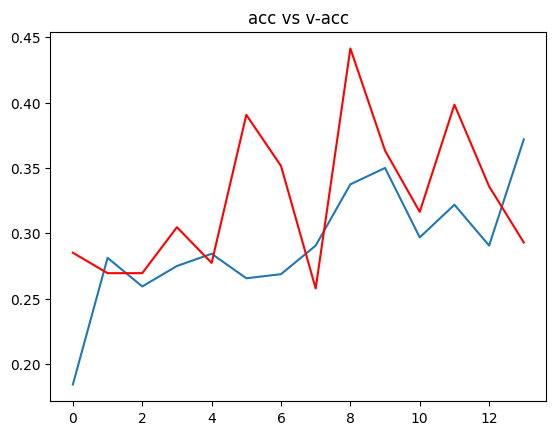

In [29]:



# Loading the best fit model 
from keras.models import load_model
model = load_model("best_model.h5")
     

h =  hist.history
h.keys()
     
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

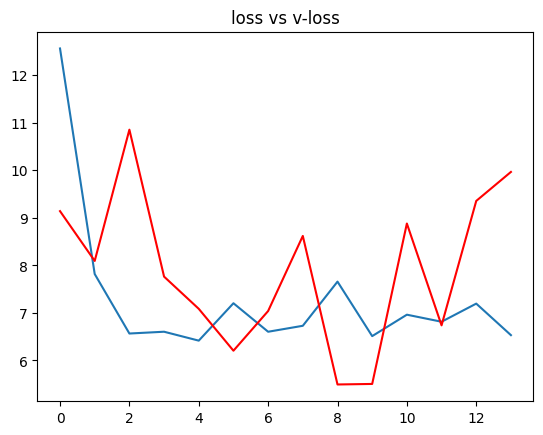

In [30]:
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
 the image is of happy


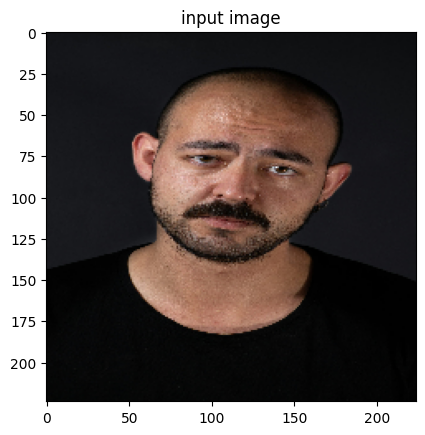

In [31]:
# just to map o/p values 
op = dict(zip( train_generator.class_indices.values(), train_generator.class_indices.keys()))
     
# path for the image to see if it predics correct class
path = "image.png"
img = load_img(path, target_size=(224,224) )

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr))

print(f" the image is of {op[pred]}")

# to display the image  
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()
     
